In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 52.9 MB/s eta 0:00:00


In [ ]:
#import brown dataset from nltk and convert it to a list of words
import nltk
from nltk.corpus import brown
from gensim.utils import simple_preprocess
nltk.download("brown")

sentences = brown.sents()

processed_sentence = [simple_preprocess(" ".join(words)) for words in sentences]

print(sentences)

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!


[['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.'], ['The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the', 'praise', 'and', 'thanks', 'of', 'the', 'City', 'of', 'Atlanta', "''", 'for', 'the', 'manner', 'in', 'which', 'the', 'election', 'was', 'conducted', '.'], ...]


In [ ]:
#train word to vec model
from gensim.models import Word2Vec

model = Word2Vec(processed_sentence, vector_size=100, window=5, min_count=2, workers=4, sg=0)

model.save("word2vec.model")
model = Word2Vec.load("word2vec.model")

In [ ]:
#use the model
similar = model.wv.most_similar('learning', topn=10)
print(similar)

[('joy', 0.9736331701278687), ('consequences', 0.9715178608894348), ('direct', 0.9659543633460999), ('success', 0.964129626750946), ('competition', 0.9640423655509949), ('survival', 0.9638340473175049), ('solutions', 0.9622503519058228), ('justification', 0.9615409970283508), ('insight', 0.9609605669975281), ('mutual', 0.9605542421340942)]


In [ ]:
vector = model.wv["learning"]
print(vector)

[-8.29978064e-02  3.92381847e-01 -2.74592843e-02 -5.21699116e-02
 -1.01971656e-01 -4.48647350e-01  2.35034257e-01  5.36973059e-01
 -2.44895861e-01 -2.90150464e-01 -3.05108670e-02 -2.62492180e-01
  8.44679307e-03  8.68553482e-03  1.20210938e-01 -3.52031946e-01
 -7.18374155e-04 -1.76056132e-01 -6.34593070e-02 -2.65926749e-01
  2.20921218e-01  1.98166296e-01  4.03218567e-01 -1.64847136e-01
 -5.56253381e-02  3.97743322e-02 -9.22407955e-02  2.29122579e-01
 -3.63039672e-01  1.89190432e-02  8.80962312e-02  7.33390749e-02
  2.95551270e-01 -3.45105320e-01 -3.40024121e-02  3.08898985e-01
  1.89701170e-01 -4.53138649e-02 -1.12812556e-01 -1.60678953e-01
 -3.88288312e-02 -1.32609800e-01 -4.72752601e-01  8.21258500e-02
  2.41254568e-01 -1.79817319e-01 -2.45276794e-01 -1.56680658e-01
 -8.33642036e-02  2.50960022e-01  2.78488725e-01 -3.38101029e-01
 -2.18620420e-01 -3.60948801e-01  1.47912025e-01 -4.93910164e-02
  2.61058480e-01 -5.64435236e-02  2.09637824e-02  2.21690342e-01
  1.88660368e-01 -1.73596

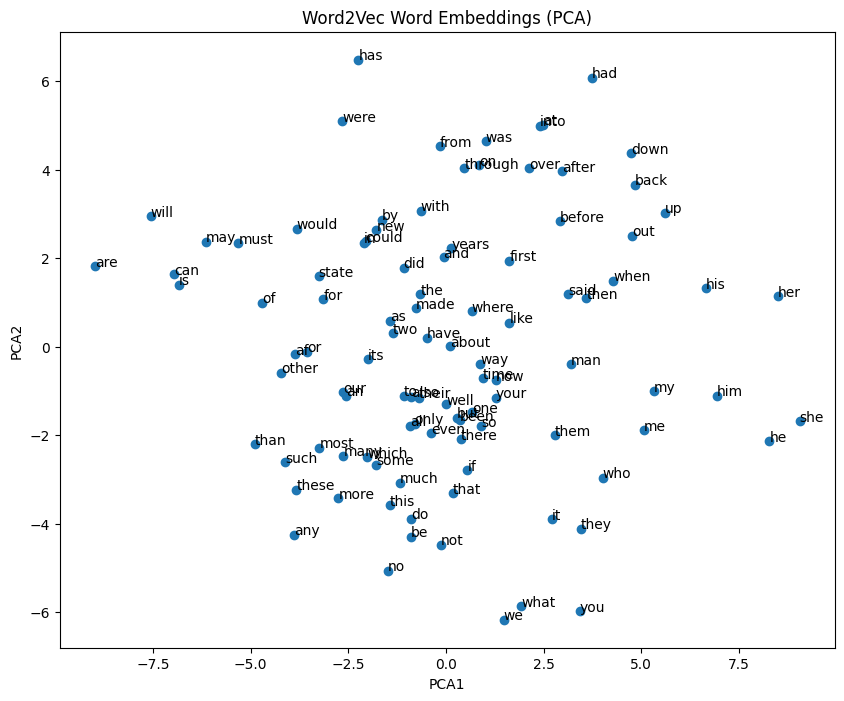

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model.wv.index_to_key)[:100]
words_vectors = model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(words_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (result[i, 0], result[i, 1]))

plt.title("Word2Vec Word Embeddings (PCA)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

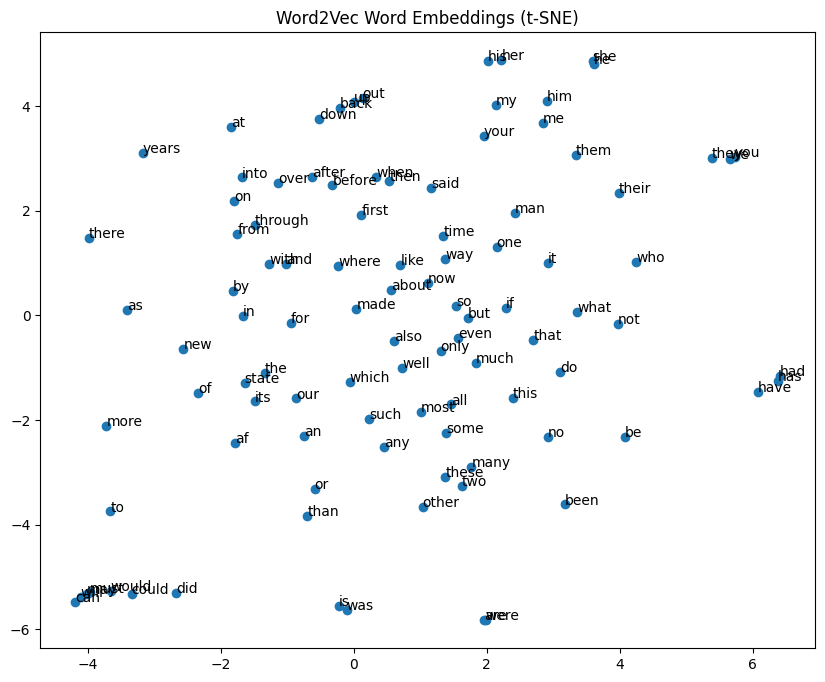

In [ ]:
from sklearn.manifold import TSNE

# Perform t-SNE
tsne = TSNE(n_components=2, random_state=0)
result = tsne.fit_transform(words_vectors)

# Plot the words
plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (result[i, 0], result[i, 1]))

plt.title("Word2Vec Word Embeddings (t-SNE)")
plt.show()


In [ ]:
vocab = "hello"
vocab_size = len(vocab)

char_to_idx = {char:idx for idx, char in enumerate(vocab)}
idx_to_char = {idx:char for idx, char in enumerate(vocab)}

sequences = ['h','e','l','l','o']
labels = ['e','l','l','o','h']

print(char_to_idx, idx_to_char)

{'h': 0, 'e': 1, 'l': 3, 'o': 4} {0: 'h', 1: 'e', 2: 'l', 3: 'l', 4: 'o'}


In [ ]:
import torch

def prepare_dataset(sequences, labels):
  x = [[char_to_idx[seq]] for seq in sequences]
  y = [char_to_idx[char] for char in labels]
  return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

x,y  = prepare_dataset(sequences,labels)

x,y

(tensor([[0],
         [1],
         [3],
         [3],
         [4]]),
 tensor([1, 3, 3, 4, 0]))

In [ ]:
import torch.nn as nn
import torch.optim as optim

class SimpleRNN(nn.Module):
  def __init__(self,input_size, hidden_size, output_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.embedding = nn.Embedding(num_embeddings=input_size,embedding_dim=hidden_size)
    self.RNN = nn.RNN(input_size=hidden_size,hidden_size=hidden_size,batch_first=True)
    self.fc = nn.Linear(in_features=hidden_size,out_features=output_size)
  def forward(self, x, hidden):
    x = self.embedding(x)
    out, hidden = self.RNN(x,hidden)
    #[:,-1,:] this is used to get the last layer
    out = self.fc(out[:, -1,:])
    return out, hidden

  def init_hidden(self):
    return torch.zeros(1,1,self.hidden_size)

input_size = vocab_size
output_size = vocab_size
hidden_size = 10
num_epoch = 500
learning_rate = 0.01

model = SimpleRNN(input_size, hidden_size, output_size)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate)

for epoch in range(num_epoch):
  hidden = model.init_hidden()
  for i in range(len(x)):
    input_seq = x[i].unsqueeze(0)
    label = y[i].unsqueeze(0)
    output,hidden = model(input_seq, hidden.detach())
    loss = loss_fn(output,label)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  if (epoch + 1) % 50 == 0:
    print(f'Epoch [{epoch+1}/{num_epoch}], Loss: {loss.item():.4f}')

with torch.no_grad():
  test_seq = 'hell'
  input_seq = torch.tensor([[char_to_idx[char] for char in test_seq]], dtype=torch.long)
  hidden = model.init_hidden()
  output, _ = model(input_seq, hidden)
  predicted_idx = torch.argmax(output, dim=1).item()
  print(f'Input: "{test_seq}", Predicted Next Character: "{idx_to_char[predicted_idx]}"')

Epoch [50/500], Loss: 0.0245
Epoch [100/500], Loss: 0.0073
Epoch [150/500], Loss: 0.0037
Epoch [200/500], Loss: 0.0023
Epoch [250/500], Loss: 0.0016
Epoch [300/500], Loss: 0.0011
Epoch [350/500], Loss: 0.0009
Epoch [400/500], Loss: 0.0007
Epoch [450/500], Loss: 0.0005
Epoch [500/500], Loss: 0.0004
Input: "hell", Predicted Next Character: "o"


In [1]:
sentence = "Life is short, eat dessert first"

dc = {s:i for i,s in enumerate(sorted(sentence.replace(',','').split()))}
print(dc)

{'Life': 0, 'dessert': 1, 'eat': 2, 'first': 3, 'is': 4, 'short': 5}


In [3]:
import torch

sentence_int = torch.tensor([dc[s] for s in sentence.replace(',','').split()])
print(sentence_int)

tensor([0, 4, 5, 2, 1, 3])


In [7]:
torch.manual_seed(42)
embed = torch.nn.Embedding(6,16)
embedded_sentence = embed(sentence_int).detach()

print(embedded_sentence)
print(embedded_sentence.shape)

tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047,
         -0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,  0.7624],
        [ 1.4451,  0.8564,  2.2181,  0.5232,  0.3466, -0.1973, -1.0546,  1.2780,
         -0.1722,  0.5238,  0.0566,  0.4263,  0.5750, -0.6417, -2.2064, -0.7508],
        [ 0.0109, -0.3387, -1.3407, -0.5854,  0.5362,  0.5246,  1.1412,  0.0516,
          0.7440, -0.4816, -1.0495,  0.6039, -1.7223, -0.8278,  1.3347,  0.4835],
        [-1.3847, -0.8712, -0.2234,  1.7174,  0.3189, -0.4245,  0.3057, -0.7746,
         -1.5576,  0.9956, -0.8798, -0.6011, -1.2742,  2.1228, -1.2347, -0.4879],
        [ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806,
          1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,  0.8599],
        [-0.9138, -0.6581,  0.0780,  0.5258, -0.4880,  1.1914, -0.8140, -0.7360,
         -1.4032,  0.0360, -0.0635,  0.6756, -0.0978,  1.8446, -1.1845,  1.3835]])
torch.Size([6, 16])


In [8]:
torch.manual_seed(42)

d = embedded_sentence.shape[1]
d_q, d_k, d_v = 24,24,28

In [9]:
w_query = torch.nn.Parameter(torch.rand(d_q,d))
w_key = torch.nn.Parameter(torch.rand(d_k,d))
w_value = torch.nn.Parameter(torch.rand(d_v,d))

In [10]:
w_query

Parameter containing:
tensor([[0.8823, 0.9150, 0.3829, 0.9593, 0.3904, 0.6009, 0.2566, 0.7936, 0.9408,
         0.1332, 0.9346, 0.5936, 0.8694, 0.5677, 0.7411, 0.4294],
        [0.8854, 0.5739, 0.2666, 0.6274, 0.2696, 0.4414, 0.2969, 0.8317, 0.1053,
         0.2695, 0.3588, 0.1994, 0.5472, 0.0062, 0.9516, 0.0753],
        [0.8860, 0.5832, 0.3376, 0.8090, 0.5779, 0.9040, 0.5547, 0.3423, 0.6343,
         0.3644, 0.7104, 0.9464, 0.7890, 0.2814, 0.7886, 0.5895],
        [0.7539, 0.1952, 0.0050, 0.3068, 0.1165, 0.9103, 0.6440, 0.7071, 0.6581,
         0.4913, 0.8913, 0.1447, 0.5315, 0.1587, 0.6542, 0.3278],
        [0.6532, 0.3958, 0.9147, 0.2036, 0.2018, 0.2018, 0.9497, 0.6666, 0.9811,
         0.0874, 0.0041, 0.1088, 0.1637, 0.7025, 0.6790, 0.9155],
        [0.2418, 0.1591, 0.7653, 0.2979, 0.8035, 0.3813, 0.7860, 0.1115, 0.2477,
         0.6524, 0.6057, 0.3725, 0.7980, 0.8399, 0.1374, 0.2331],
        [0.9578, 0.3313, 0.3227, 0.0162, 0.2137, 0.6249, 0.4340, 0.1371, 0.5117,
         0.1585

In [11]:
w_query.size()

torch.Size([24, 16])

In [12]:
x_2 = embedded_sentence[1]
x_2

tensor([ 1.4451,  0.8564,  2.2181,  0.5232,  0.3466, -0.1973, -1.0546,  1.2780,
        -0.1722,  0.5238,  0.0566,  0.4263,  0.5750, -0.6417, -2.2064, -0.7508])

In [13]:
x_2.shape

torch.Size([16])

In [14]:
query_2 = w_query.matmul(x_2)
key_2 = w_key.matmul(x_2)
value_2 = w_value.matmul(x_2)

print(query_2.shape)
print(key_2.shape)
print(value_2.shape)

torch.Size([24])
torch.Size([24])
torch.Size([28])


In [15]:
embedded_sentence.shape

torch.Size([6, 16])

In [16]:
keys = w_key.matmul(embedded_sentence.T).T
values = w_value.matmul(embedded_sentence.T).T

print("keys.shape",keys.shape)
print("values.shape",values.shape)

keys.shape torch.Size([6, 24])
values.shape torch.Size([6, 28])


In [17]:
omega_24 = query_2.dot(keys[4])
print(omega_24)

tensor(220.2759, grad_fn=<DotBackward0>)


Attention Weights:
 tensor([[[0.3897, 0.4070, 0.2034],
         [0.2914, 0.3184, 0.3901],
         [0.3001, 0.4153, 0.2846]]])
Output:
 tensor([[[-0.4852, -0.6369,  0.7000,  0.2580],
         [-0.3236, -0.7298,  0.1953,  0.2234],
         [-0.5025, -0.6306,  0.5419,  0.1526]]])


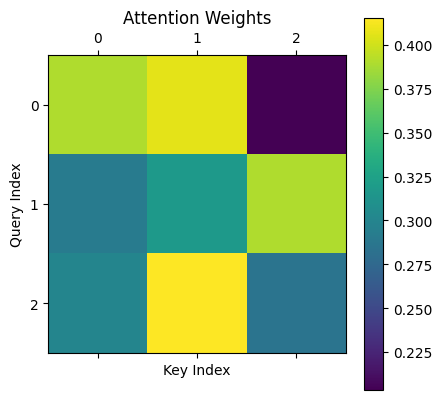

In [20]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def scaled_dot_product_attention(query, key,value):
  d_k = query.size(-1)

  scores = torch.matmul(query, key.transpose(-2, -1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

  attention_weights = F.softmax(scores, dim=-1)

  output = attention_weights @ value
  return output, attention_weights

batch_size, seq_len , d_k , d_v = 1,3,4,4
query = torch.randn(batch_size, seq_len, d_k)
key = torch.randn(batch_size, seq_len, d_k)
value = torch.randn(batch_size, seq_len, d_v)

output, attention_weights = scaled_dot_product_attention(query, key, value)


print("Attention Weights:\n", attention_weights)
print("Output:\n", output)

# Step 5: Visualizing Attention Weights
# Visualize attention weights
plt.matshow(attention_weights[0].detach().numpy(), cmap='viridis')
plt.colorbar()
plt.title("Attention Weights")
plt.xlabel("Key Index")
plt.ylabel("Query Index")
plt.show()

In [21]:
# Importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [22]:
# Sample sentences for demonstration
sentences = [
    "I am learning attention mechanisms",
    "Attention is a powerful tool for NLP",
    "Understanding attention is crucial for deep learning",
    "The cat sat on the mat"
]

# Sample vocabulary (a simplified version)
vocab = ['I', 'am', 'learning', 'attention', 'mechanisms', 'is', 'a', 'powerful', 'tool', 'for', 'NLP', 'understanding', 'crucial', 'deep', 'learning', "The", "cat", "sat", "on", "mat", "the"]
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

# Function to convert a sentence to indices
def sentence_to_indices(sentence):
    return [word2idx[word] for word in sentence.split()]


In [23]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.hidden_size = hidden_size

    def forward(self, query, key, value):
        # Step 1: Compute the dot-product of query and key
        scores = torch.matmul(query, key.transpose(-2, -1)) / np.sqrt(self.hidden_size)

        # Step 2: Apply softmax to get the attention weights
        attention_weights = torch.nn.functional.softmax(scores, dim=-1)

        # Step 3: Multiply the attention weights by the value to get the context
        context = torch.matmul(attention_weights, value)

        return context, attention_weights


In [24]:
class EmbeddingLayer(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(EmbeddingLayer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, x):
        return self.embedding(x)


In [25]:
# Hyperparameters
embedding_dim = 8
hidden_size = 8
max_len = 10

# Initialize models
embedding_layer = EmbeddingLayer(len(vocab), embedding_dim).to(device)
attention = Attention(hidden_size).to(device)

# Function to generate the Query, Key, and Value tensors
def generate_qkv(sentence):
    sentence_indices = torch.tensor(sentence_to_indices(sentence)).unsqueeze(0).to(device)  # Shape: (1, seq_len)

    # Get embeddings for the sentence
    embeddings = embedding_layer(sentence_indices)

    # For simplicity, let's use the same embeddings as query, key, and value
    query = embeddings
    key = embeddings
    value = embeddings

    return query, key, value

# Example sentence
sentence = "The cat sat on the mat"

# Generate Q, K, V
query, key, value = generate_qkv(sentence)

# Apply attention mechanism
context, attention_weights = attention(query, key, value)

print("Context:", context)
print("Attention Weights:", attention_weights)


Context: tensor([[[-0.8423, -1.0199, -0.8858, -0.7677,  0.3872,  0.8057,  0.1141,
           0.6554],
         [-1.3635, -1.5760, -2.0207, -0.4142, -0.5288,  0.3400, -0.7591,
          -1.1260],
         [-0.5000, -0.7794, -0.7987, -0.7974,  0.5023,  0.9716, -0.1974,
           0.5684],
         [-0.7529, -0.5188, -1.0507, -0.7519,  0.1016,  0.7830, -0.0689,
           0.3624],
         [-0.4148, -1.1590, -0.4785, -0.8726,  0.7986,  1.2000, -0.1288,
           0.8665],
         [-0.5496, -0.4749, -0.6908, -0.7594,  0.4255,  0.9678,  0.1503,
           0.7654]]], grad_fn=<UnsafeViewBackward0>)
Attention Weights: tensor([[[0.3978, 0.1362, 0.0785, 0.0887, 0.2133, 0.0857],
         [0.0393, 0.8892, 0.0199, 0.0282, 0.0180, 0.0055],
         [0.1371, 0.1202, 0.2403, 0.1209, 0.2798, 0.1017],
         [0.1676, 0.1844, 0.1308, 0.2790, 0.1024, 0.1359],
         [0.1659, 0.0484, 0.1246, 0.0421, 0.5522, 0.0667],
         [0.1977, 0.0437, 0.1344, 0.1660, 0.1980, 0.2602]]],
       grad_fn=<SoftmaxBa

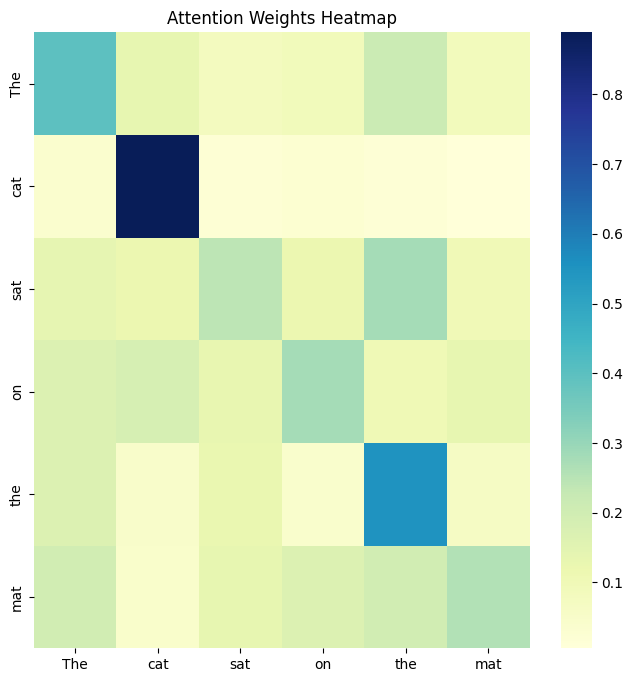

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention_weights(sentence, attention_weights):
    attention_weights = attention_weights.squeeze(0).cpu().detach().numpy()  # Shape: (seq_len, seq_len)

    fig, ax = plt.subplots(figsize=(8, 8))
    sns.heatmap(attention_weights, xticklabels=sentence.split(), yticklabels=sentence.split(), cmap="YlGnBu", cbar=True, ax=ax)
    plt.title("Attention Weights Heatmap")
    plt.show()

# Plot attention weights for the example sentence
plot_attention_weights(sentence, attention_weights)


In [27]:
! pip install bertviz transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.6 MB/s eta 0:00:00


In [28]:
from bertviz import model_view, head_view
from transformers import AutoTokenizer, AutoModel, utils

utils.logging.set_verbosity_error()  # Suppress standard warnings

In [29]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased", output_attentions=True)
inputs = tokenizer.encode("The cat sat on the mat", return_tensors='pt')
outputs = model(inputs)
attention = outputs[-1]  # Output includes attention weights when output_attentions=True
tokens = tokenizer.convert_ids_to_tokens(inputs[0])
head_view(attention, tokens)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

In [30]:
model_view(attention, tokens)

<IPython.core.display.Javascript object>